<a href="https://colab.research.google.com/github/piyushanangude/Codetech/blob/main/Task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Preview:
   Row ID+O6G3A1:R6        Order ID  Order Date   Ship Date       Ship Mode  \
0              4918  CA-2019-160304  01-01-2019  07-01-2019  Standard Class   
1              4919  CA-2019-160304  02-01-2019  07-01-2019  Standard Class   
2              4920  CA-2019-160304  02-01-2019  07-01-2019  Standard Class   
3              3074  CA-2019-125206  03-01-2019  05-01-2019     First Class   
4              8604  US-2019-116365  03-01-2019  08-01-2019  Standard Class   

  Customer ID      Customer Name    Segment        Country          City  ...  \
0    BM-11575      Brendan Murry  Corporate  United States  Gaithersburg  ...   
1    BM-11575      Brendan Murry  Corporate  United States  Gaithersburg  ...   
2    BM-11575      Brendan Murry  Corporate  United States  Gaithersburg  ...   
3    LR-16915       Lena Radford   Consumer  United States   Los Angeles  ...   
4    CA-12310  Christine Abelman  Corporate  United States   San Antonio  ...   

          Category Su

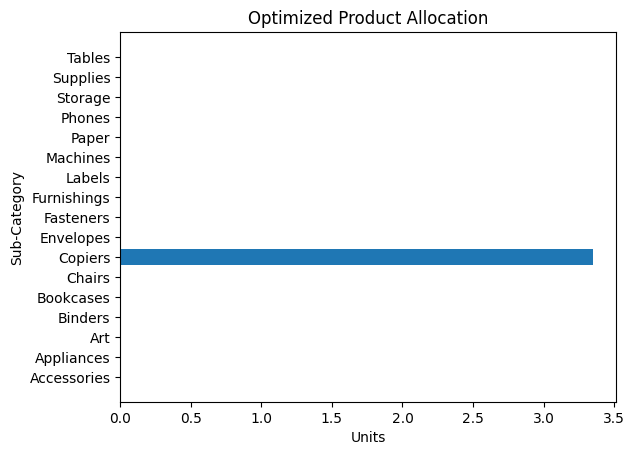


Key Insights:
- Optimization identifies most profitable product mix.
- Helps allocate limited inventory efficiently.
- Shows which product categories should be prioritized.
- Supports better supply chain and business decisions.


In [2]:
# ================================
# STEP 1: Install & Import Libraries
# ================================
!pip install pulp pandas matplotlib

import pandas as pd
import matplotlib.pyplot as plt
from pulp import LpMaximize, LpProblem, LpVariable, LpStatus, value

# ================================
# STEP 2: Load Real Dataset
# ================================
# Download "SampleSuperstore.csv" from Kaggle and place in same folder

df = pd.read_csv("SuperStore_Sales_Dataset.csv")

print("Dataset Preview:")
print(df.head())

# ================================
# STEP 3: Data Preprocessing
# ================================
# Aggregate data by Sub-Category

product_data = df.groupby('Sub-Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).reset_index()

print("\nAggregated Data:")
print(product_data)

# ================================
# STEP 4: Define Constraints
# ================================
max_quantity = 5000     # Inventory capacity
max_sales = 200000      # Shipping budget constraint

# ================================
# STEP 5: Create Optimization Model
# ================================
model = LpProblem("Retail_Optimization", LpMaximize)

# ================================
# STEP 6: Decision Variables
# ================================
variables = {
    row['Sub-Category']: LpVariable(name=row['Sub-Category'], lowBound=0)
    for _, row in product_data.iterrows()
}

# ================================
# STEP 7: Objective Function (Max Profit)
# ================================
model += sum(
    row['Profit'] * variables[row['Sub-Category']]
    for _, row in product_data.iterrows()
)

# ================================
# STEP 8: Constraints
# ================================

# Inventory constraint
model += sum(
    row['Quantity'] * variables[row['Sub-Category']]
    for _, row in product_data.iterrows()
) <= max_quantity

# Sales / Shipping constraint
model += sum(
    row['Sales'] * variables[row['Sub-Category']]
    for _, row in product_data.iterrows()
) <= max_sales

# ================================
# STEP 9: Solve Model
# ================================
model.solve()

# ================================
# STEP 10: Results
# ================================
print("\nStatus:", LpStatus[model.status])

print("\nOptimal Product Allocation:")
results = {}

for product, var in variables.items():
    results[product] = var.value()
    print(f"{product}: {var.value()}")

print("\nMaximum Profit:", value(model.objective))

# ================================
# STEP 11: Visualization
# ================================
products = list(results.keys())
values = list(results.values())

plt.figure()
plt.barh(products, values)
plt.title("Optimized Product Allocation")
plt.xlabel("Units")
plt.ylabel("Sub-Category")
plt.show()

# ================================
# STEP 12: Insights
# ================================
print("\nKey Insights:")
print("- Optimization identifies most profitable product mix.")
print("- Helps allocate limited inventory efficiently.")
print("- Shows which product categories should be prioritized.")
print("- Supports better supply chain and business decisions.")